In [2]:
import numpy as np
import csv
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import preprocessing
from tensorflow.keras.layers import Normalization, Resizing
from tensorflow.keras import layers
from tensorflow.keras import models
from sklearn.utils.class_weight import compute_class_weight

import pandas as pd

import seaborn as sns

from scipy import signal
from scipy.signal import butter, filtfilt, iirnotch, periodogram

In [5]:
scratch_np = np.load('scratch.npy', allow_pickle=True)
rest_np = np.load('rest.npy', allow_pickle=True)
other_np = np.load('other.npy', allow_pickle=True)

In [31]:
def normalize(data):
    data = data - np.mean(data)
    data = (data - data.min()) / (data.max() - data.min())
    return data

def bandpass_filter(data, lowcut=20.0, highcut=200.0, fs=1000.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, data)

def find_noise_frequency(data, fs=1000.0):
    f, Pxx = periodogram(data, fs=fs)
    idx = np.argmax(Pxx)
    return f[idx]

def adaptive_notch_filter(data, fs=1000.0, quality=30):
    freq = find_noise_frequency(data, fs=fs)
    nyq = 0.5 * fs
    b, a = iirnotch(freq/nyq, quality)
    return filtfilt(b, a, data)

def cleanup(data):
    data = normalize(data)
    data = bandpass_filter(data)
    data = adaptive_notch_filter(data)
    return data

def stft(x, sampling_rate=1000):
    f, t, spec = signal.stft(x.numpy(), fs=sampling_rate, nperseg=255, noverlap = 50, nfft=256, boundary='zeros')
    return tf.convert_to_tensor(np.abs(spec))

def stft_full(x, sampling_rate=1000, useNp=False): # for visualization
    if not useNp:
        X = x.numpy()
    else:
        X = x
    f, t, spec = signal.stft(X, fs=sampling_rate, nperseg=255, noverlap = 50, nfft=256, boundary='zeros')
    return f, t, tf.convert_to_tensor(np.abs(spec))

def get_spectrogram(data: np.ndarray):
    # f, t, z = signal.stft(data, fs=200, nperseg=128, noverlap=50, nfft=128)
    spectrogram = tf.py_function(func=stft, inp=[data], Tout=tf.float32)
    spectrogram = tf.image.resize(spectrogram[..., tf.newaxis], [129, 124])
    spectrogram = tf.squeeze(spectrogram, -1)
    # spectrogram.set_shape((129, 124))
    return spectrogram

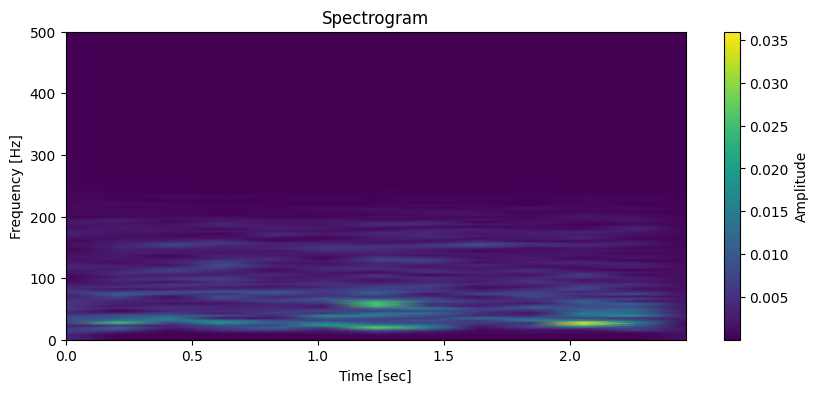

In [34]:
current_array = scratch_np[:]

current_array = cleanup(current_array)

f, t, spec = stft_full(current_array, sampling_rate=1000, useNp=True)

plt.figure(figsize=(10, 4))
plt.pcolormesh(t, f, spec, shading='gouraud')
plt.title('Spectrogram')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar(label='Amplitude')  # limit frequency range to make plot clearer
# plt.savefig('scratch_data_800Hz.png')
plt.show()